In [3]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


NB_DIR = Path.cwd().resolve()
PROJECT_DIR = NB_DIR.parent.parent
FLOW_DIR = PROJECT_DIR / "z.flow_postprocessing"
FLOW_SCRIPTS_DIR = FLOW_DIR / "scripts"

for path in [PROJECT_DIR, FLOW_SCRIPTS_DIR]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)

import theme.plot_theme as ptheme
import shcherbina_utils as shu

importlib.reload(ptheme)
ptheme.apply_theme()
importlib.reload(shu)
shu.apply_plot_style()

print(f"Notebook dir     : {NB_DIR}")
print(f"Project dir      : {PROJECT_DIR}")
print(f"Flow scripts dir : {FLOW_SCRIPTS_DIR}")



Notebook dir     : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\notebooks
Project dir      : C:\Users\Jelle Gortemaker\Documents\Thesis
Flow scripts dir : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\scripts


Opening glued state diagnostics...
time_dim          : T
z_dim             : Zmd000002
n time steps      : 160
n vertical levels : 2
LAYER_MODE (k)       : 0
selected snapshot : index 0 -> t = 0.0 days
square grid       : 4 x 4
Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1\rossby_map_k0_t0000.png


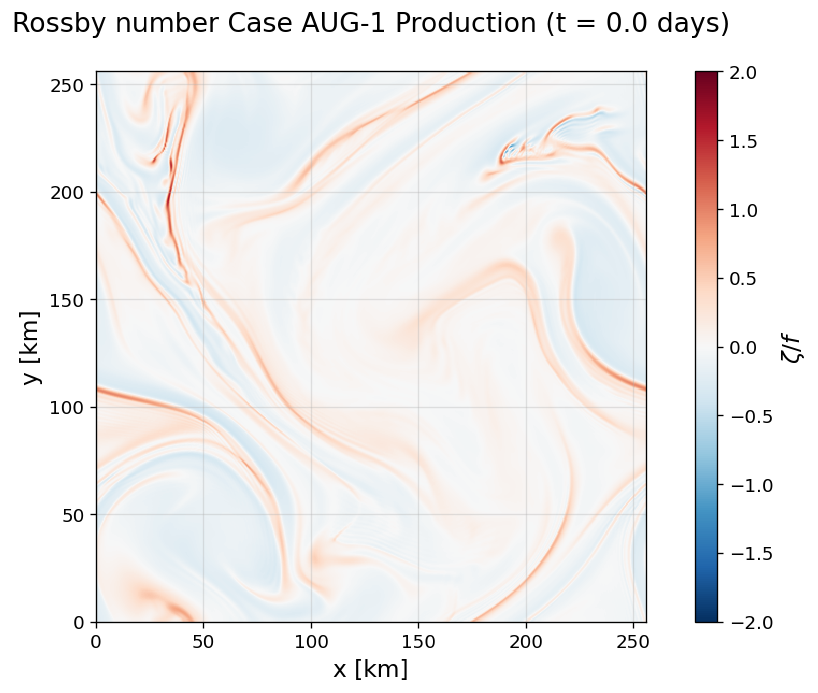

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1\divergence_map_k0_t0000.png


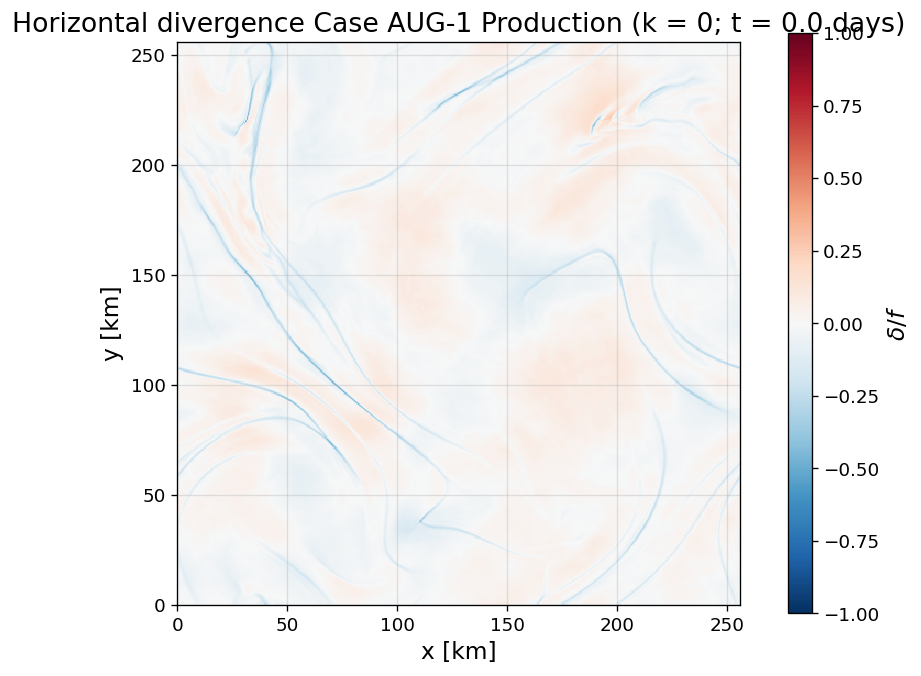

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1\jpdf_vorticity_strain_k0_t0000.png


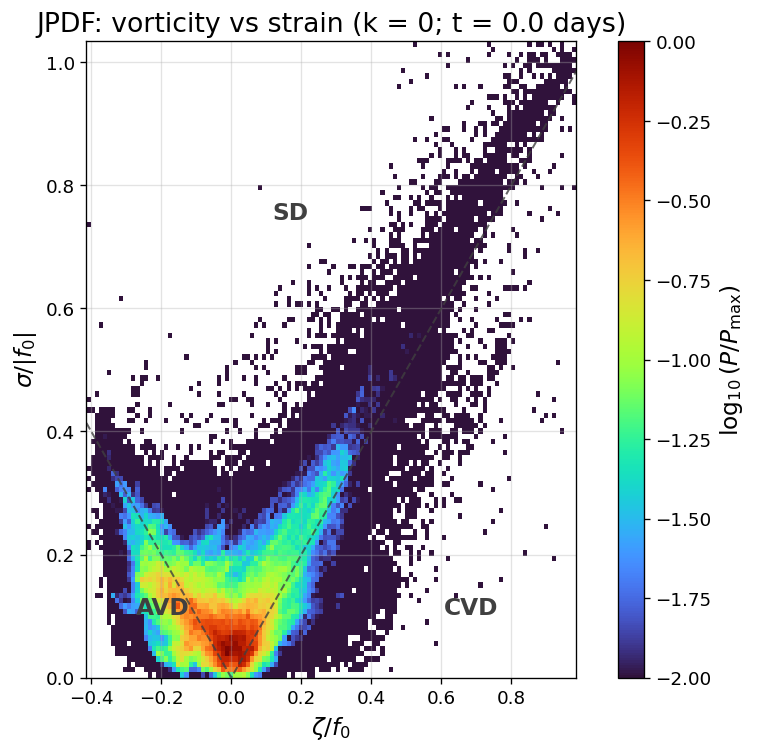

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1\jpdf_vorticity_divergence_k0_t0000.png


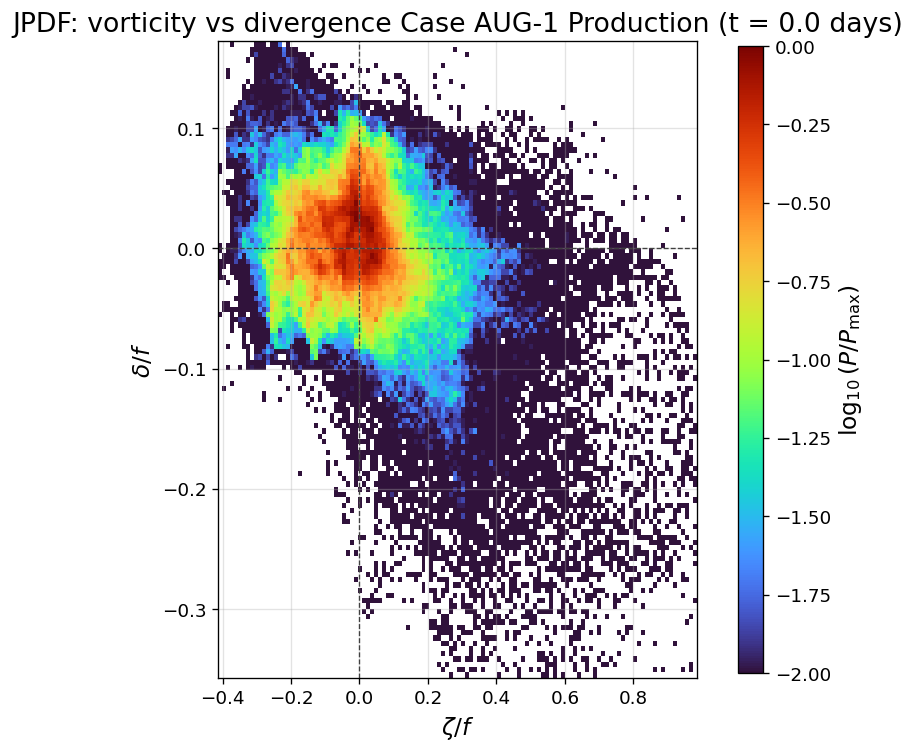

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1\rossby_squares_k0_t0000.png


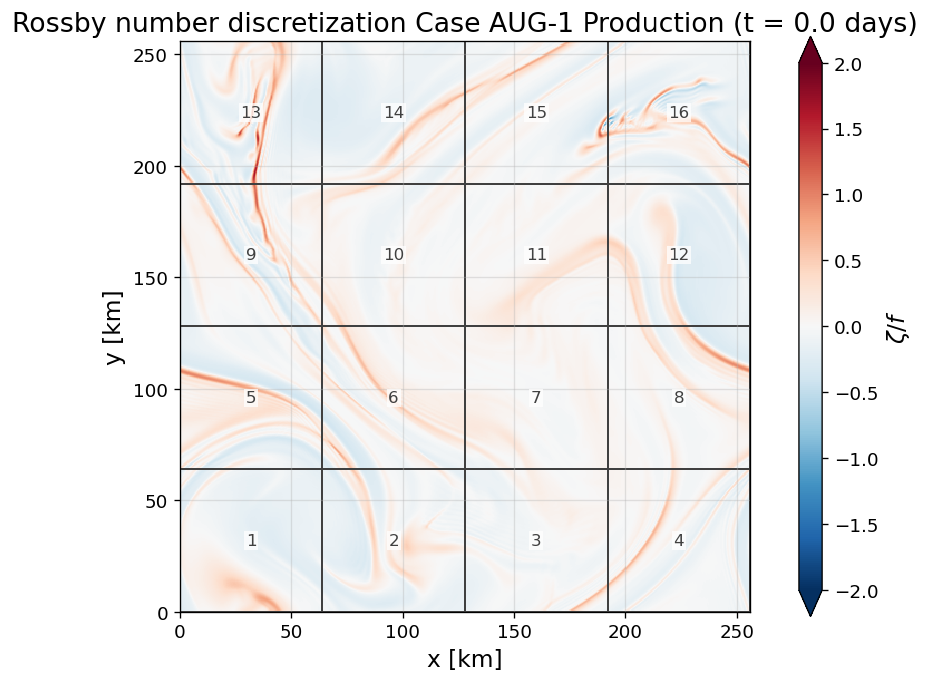

Saved: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1\pro_per_square_timeseries_run_aug1_4x4.png


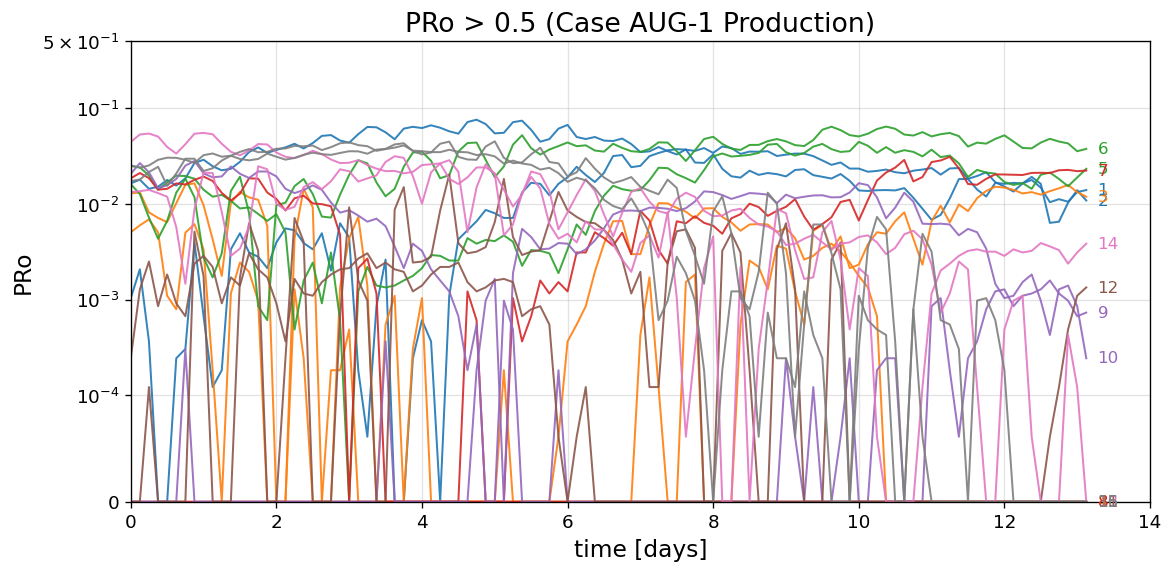


Notebook variables now available:
  ds
  ro, div_f, strain_f
  H_vs, H_vs_log
  H_vd, H_vd_log
  squares
  square_metrics_df
  square_pro_wide


In [4]:
# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
NB_DIR = Path.cwd()

case_name = "run_aug1"
RUN_TITLE_INFO = "Case AUG-1 Production"


DATA_FILE = (NB_DIR / f"../data/input/{case_name}.nc").resolve()
UTILS_PATH = (NB_DIR / "../scripts").resolve()
MODULE_NAME = "shcherbina_utils"

OUT_DIR = (NB_DIR / f"../results/{case_name}").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_FILE.exists():
    raise FileNotFoundError(f"Could not find glued state file at:\n{DATA_FILE}")

SAVE = True
MAKE_ROSSBY_SNAPSHOTS = True


# DX = 250.0
# DY = 250.0
DX = 500.0
DY = 500.0
# DX = 1000.0
# DY = 1000.0
F0 = 8.0e-5

SELECTED_TIME_INDEX = 0 * 8
DAY_PER_INDEX = 0.5 / 4

N_SQUARES_X = 4
N_SQUARES_Y = 4

nbins_pdf = 80
nbins_jpdf = 120

PRo_threshold = 0.5

# ------------------------------------------------------------
# OPTIONAL LOCAL-AREA JPDF SETTINGS
# ------------------------------------------------------------
ENABLE_LOCAL_JPDF = False   # set False to disable both rectangle and local JPDF

# Manually selected square area in km, based on the Rossby-number map axes.
# The square starts at (LOCAL_BOX_X0_KM, LOCAL_BOX_Y0_KM)
# and extends LOCAL_BOX_SIZE_KM in both x and y.
LOCAL_BOX_X0_KM = 50.0
LOCAL_BOX_Y0_KM = 60.0
LOCAL_BOX_SIZE_KM = 50.0

# If True, local JPDF uses the same bin edges as the full-domain JPDF.
# This makes the local and full-domain JPDFs directly comparable.
# If False, the local JPDF gets its own percentile-based bin edges.
LOCAL_JPDF_USE_GLOBAL_EDGES = True
LOCAL_JPDF_NBINS = nbins_jpdf

LOCAL_BOX_EDGE_COLOR = "black"
LOCAL_BOX_LINEWIDTH = 1.5

# Extra field plots
TEMP_VAR = "THETA"
TEMP_LEVEL_INDEX = 0
TEMP_CMAP = "turbo"
TEMP_PERCENTILE_LIMITS = (1, 99)

W_VAR = "WVEL"
W_LEVEL_INDEX = 0 # 1
LAYER_MODE = f"k={W_LEVEL_INDEX}"
W_CONVERT_TO_M_PER_DAY = True
W_PERCENTILE_LIMIT = 98

# Shared plotting style
shu.apply_plot_style()
FONT_SIZE = getattr(ptheme, "FONT_SIZE", 14)
TITLE_SIZE = getattr(ptheme, "TITLE_SIZE", FONT_SIZE)
SAVE_DPI = getattr(ptheme, "SAVE_DPI", 300)


# ------------------------------------------------------------
# IMPORT HELPERS / APPLY STYLE
# ------------------------------------------------------------
if str(UTILS_PATH) not in sys.path:
    sys.path.insert(0, str(UTILS_PATH))

importlib.reload(ptheme)
ptheme.apply_theme()

shu = importlib.import_module(MODULE_NAME)
importlib.reload(shu)
shu.apply_plot_style()


# ------------------------------------------------------------
# OPEN DATA
# ------------------------------------------------------------
print("Opening glued state diagnostics...")
ds = xr.open_dataset(DATA_FILE, chunks="auto")

required_vars = ["UVEL", "VVEL"]
for var in required_vars:
    if var not in ds:
        raise KeyError(f"Required variable '{var}' not found in dataset.")

has_theta = TEMP_VAR in ds.variables
has_wvel = W_VAR in ds.variables

if not has_theta:
    print(f"Warning: {TEMP_VAR} not found. Surface temperature plot will be skipped.")

if not has_wvel:
    print(f"Warning: {W_VAR} not found. Conditional vertical velocity plot will be skipped.")

time_dim = shu.find_dim(ds.dims, ["T", "time", "iter"])
z_dim = shu.find_dim(ds["UVEL"].dims, ["Z", "Zmd", "k", "depth"])

if has_theta:
    theta_z_dim = shu.find_dim(ds[TEMP_VAR].dims, ["Z", "Zmd", "k", "depth"])
else:
    theta_z_dim = None

if has_wvel:
    w_z_dim = shu.find_dim(ds[W_VAR].dims, ["Zl", "Z", "Zmd", "k", "depth"])
else:
    w_z_dim = None

nt = ds.sizes[time_dim]
nz = ds.sizes[z_dim]

if W_LEVEL_INDEX < 0 or W_LEVEL_INDEX >= nz:
    raise IndexError(f"W_LEVEL_INDEX={W_LEVEL_INDEX} is invalid; nz={nz}")

if not (0 <= int(SELECTED_TIME_INDEX) < nt):
    raise IndexError(f"SELECTED_TIME_INDEX={SELECTED_TIME_INDEX} out of range for nt={nt}")

if has_theta:
    ntheta = ds.sizes[theta_z_dim]
    if not (0 <= int(TEMP_LEVEL_INDEX) < ntheta):
        raise IndexError(f"TEMP_LEVEL_INDEX={TEMP_LEVEL_INDEX} out of range for {TEMP_VAR}; ntheta={ntheta}")

if has_wvel:
    nw = ds.sizes[w_z_dim]
    if not (0 <= int(W_LEVEL_INDEX) < nw):
        raise IndexError(f"W_LEVEL_INDEX={W_LEVEL_INDEX} out of range for {W_VAR}; nw={nw}")

plot_time_index = int(SELECTED_TIME_INDEX)
plot_time_days = shu.get_time_days(plot_time_index, DAY_PER_INDEX)

print(f"time_dim          : {time_dim}")
print(f"z_dim             : {z_dim}")
print(f"n time steps      : {nt}")
print(f"n vertical levels : {nz}")
print(f"LAYER_MODE (k)       : {W_LEVEL_INDEX}")
print(f"selected snapshot : index {plot_time_index} -> t = {plot_time_days:.1f} days")
print(f"square grid       : {N_SQUARES_X} x {N_SQUARES_Y}")

if has_theta:
    print(f"{TEMP_VAR} z_dim     : {theta_z_dim}")
    print(f"{TEMP_VAR} level     : {TEMP_LEVEL_INDEX}")

if has_wvel:
    print(f"{W_VAR} z_dim        : {w_z_dim}")
    print(f"{W_VAR} level        : {W_LEVEL_INDEX}")


# ------------------------------------------------------------
# SNAPSHOT FIELDS AT SELECTED TIME
# ------------------------------------------------------------
ro, div_f, strain_f = shu.compute_surface_kinematics(
    ds,
    time_dim,
    z_dim,
    plot_time_index,
    [W_LEVEL_INDEX],
    DX,
    DY,
    F0,
)

ro_1d = ro[np.isfinite(ro)]
div_1d = div_f[np.isfinite(div_f)]
strain_1d = strain_f[np.isfinite(strain_f)]

ny, nx = ro.shape

# ------------------------------------------------------------
# OPTIONAL LOCAL SQUARE AREA
# ------------------------------------------------------------
def square_box_km_to_indices(x0_km, y0_km, size_km, nx, ny, dx, dy):
    """
    Convert a manually selected square box in km to array index bounds.

    Returns a dictionary with both index bounds and actual clipped km bounds.
    Array convention: field[y, x].
    """
    x1_km = x0_km + size_km
    y1_km = y0_km + size_km

    ix0 = int(np.floor((x0_km * 1000.0) / dx))
    ix1 = int(np.ceil((x1_km * 1000.0) / dx))
    iy0 = int(np.floor((y0_km * 1000.0) / dy))
    iy1 = int(np.ceil((y1_km * 1000.0) / dy))

    ix0 = max(0, min(ix0, nx - 1))
    ix1 = max(ix0 + 1, min(ix1, nx))
    iy0 = max(0, min(iy0, ny - 1))
    iy1 = max(iy0 + 1, min(iy1, ny))

    return {
        "ix0": ix0,
        "ix1": ix1,
        "iy0": iy0,
        "iy1": iy1,
        "x0_km": ix0 * dx / 1000.0,
        "x1_km": ix1 * dx / 1000.0,
        "y0_km": iy0 * dy / 1000.0,
        "y1_km": iy1 * dy / 1000.0,
    }


if ENABLE_LOCAL_JPDF:
    local_box = square_box_km_to_indices(
        LOCAL_BOX_X0_KM,
        LOCAL_BOX_Y0_KM,
        LOCAL_BOX_SIZE_KM,
        nx,
        ny,
        DX,
        DY,
    )

    print("Local JPDF box:")
    print(
        f"  x = {local_box['x0_km']:.1f}–{local_box['x1_km']:.1f} km, "
        f"y = {local_box['y0_km']:.1f}–{local_box['y1_km']:.1f} km"
    )
    print(
        f"  ix = {local_box['ix0']}:{local_box['ix1']}, "
        f"iy = {local_box['iy0']}:{local_box['iy1']}"
    )
else:
    local_box = None

squares, square_x_edges, square_y_edges = shu.build_square_index_ranges(
    ny,
    nx,
    N_SQUARES_Y,
    N_SQUARES_X,
)


# ------------------------------------------------------------
# JPDF ARRAYS
# ------------------------------------------------------------
ro_min = np.nanpercentile(ro_1d, 0.1)
ro_max = np.nanpercentile(ro_1d, 99.9)

strain_min = max(0.0, np.nanpercentile(strain_1d, 0.1))
strain_max = np.nanpercentile(strain_1d, 99.9)

ro_pad = 0.03 * (ro_max - ro_min) if ro_max > ro_min else 0.1
st_pad = 0.03 * (strain_max - strain_min) if strain_max > strain_min else 0.1

ro_edges = np.linspace(ro_min - ro_pad, ro_max + ro_pad, nbins_jpdf + 1)
strain_edges = np.linspace(max(0.0, strain_min - st_pad), strain_max + st_pad, nbins_jpdf + 1)

H_vs, _, _ = np.histogram2d(
    ro_1d,
    strain_1d,
    bins=[ro_edges, strain_edges],
    density=True,
)

H_vs_n = H_vs / np.nanmax(H_vs) if np.nanmax(H_vs) > 0 else H_vs
H_vs_log = np.log10(np.where(H_vs_n > 0, H_vs_n, np.nan))

div_min = np.nanpercentile(div_1d, 0.1)
div_max = np.nanpercentile(div_1d, 99.9)
div_pad = 0.03 * (div_max - div_min) if div_max > div_min else 0.1

div_edges = np.linspace(div_min - div_pad, div_max + div_pad, nbins_jpdf + 1)

H_vd, _, _ = np.histogram2d(
    ro_1d,
    div_1d,
    bins=[ro_edges, div_edges],
    density=True,
)

H_vd_n = H_vd / np.nanmax(H_vd) if np.nanmax(H_vd) > 0 else H_vd
H_vd_log = np.log10(np.where(H_vd_n > 0, H_vd_n, np.nan))


# ------------------------------------------------------------
# LOCAL PRo TIME SERIES PER SQUARE
# ------------------------------------------------------------
square_metrics_records = []

for it in range(nt):
    ro_it, _, _ = shu.compute_surface_kinematics(
        ds,
        time_dim,
        z_dim,
        it,
        [W_LEVEL_INDEX],
        DX,
        DY,
        F0,
    )

    square_vals = shu.compute_pro_per_square(ro_it, squares, PRo_threshold)

    for item in square_vals:
        square_metrics_records.append({
            "time_index": int(it),
            "time_days": shu.get_time_days(it, DAY_PER_INDEX),
            "square_id": int(item["square_id"]),
            "PRo": float(item["PRo"]),
        })

square_metrics_df = pd.DataFrame(square_metrics_records)

square_pro_wide = (
    square_metrics_df
    .pivot(index="time_days", columns="square_id", values="PRo")
    .sort_index()
)


# ------------------------------------------------------------
# 1) ROSSBY NUMBER MAP
# ------------------------------------------------------------
fig, ax = shu.plot_map(
    ro,
    title=f"Rossby number {RUN_TITLE_INFO} (t = {plot_time_days:.1f} days)\n",
    cbar_label=r"$\zeta/f$",
    cmap=shu.get_cmap("rossby"),
    vmin=-2,
    vmax=2,
    dx=DX,
    dy=DY,
)

# Optional selected local area rectangle
if ENABLE_LOCAL_JPDF and local_box is not None:
    rect = Rectangle(
        (local_box["x0_km"], local_box["y0_km"]),
        local_box["x1_km"] - local_box["x0_km"],
        local_box["y1_km"] - local_box["y0_km"],
        fill=False,
        edgecolor=LOCAL_BOX_EDGE_COLOR,
        linewidth=LOCAL_BOX_LINEWIDTH,
        linestyle="-",
    )
    ax.add_patch(rect)

    ax.text(
        0.5 * (local_box["x0_km"] + local_box["x1_km"]),
        0.5 * (local_box["y0_km"] + local_box["y1_km"]),
        "local\nJPDF",
        ha="center",
        va="center",
        fontsize=9,
        color=LOCAL_BOX_EDGE_COLOR,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.65, pad=1.2),
    )

shu.savefig_if_needed(
    fig,
    f"rossby_map_k{W_LEVEL_INDEX}_t{plot_time_index:04d}",
    save=SAVE,
    out_dir=OUT_DIR,
)

plt.show()


# ------------------------------------------------------------
# 2) SURFACE TEMPERATURE MAP
# ------------------------------------------------------------
if has_theta:
    theta = shu.clean_fill(
        ds[TEMP_VAR].isel({time_dim: plot_time_index, theta_z_dim: TEMP_LEVEL_INDEX}).values
    )

    theta_plot, _ = shu.crop_to_common_shape(theta, ro)

    tmin, tmax = np.nanpercentile(theta_plot, TEMP_PERCENTILE_LIMITS)

    fig, ax = shu.plot_map(
        theta_plot,
        title=f"Surface temperature {RUN_TITLE_INFO} (t = {plot_time_days:.1f} days)",
        cbar_label=r"$\theta$",
        cmap=TEMP_CMAP,
        vmin=tmin,
        vmax=tmax,
        dx=DX,
        dy=DY,
    )

    shu.savefig_if_needed(
        fig,
        f"surface_temperature_k{W_LEVEL_INDEX}_t{plot_time_index:04d}",
        save=SAVE,
        out_dir=OUT_DIR,
    )

    plt.show()


# ------------------------------------------------------------
# 3) HORIZONTAL DIVERGENCE MAP
# ------------------------------------------------------------
fig, ax = shu.plot_map(
    div_f,
    title=f"Horizontal divergence {RUN_TITLE_INFO} (k = {W_LEVEL_INDEX}; t = {plot_time_days:.1f} days)",
    cbar_label=r"$\delta/f$",
    cmap=shu.get_cmap("rossby"),
    vmin=-1,
    vmax=1,
    dx=DX,
    dy=DY,
)

shu.savefig_if_needed(
    fig,
    f"divergence_map_k{W_LEVEL_INDEX}_t{plot_time_index:04d}",
    save=SAVE,
    out_dir=OUT_DIR,
)

plt.show()


# # ------------------------------------------------------------
# # 4) PDF FIGURE: VORTICITY / DIVERGENCE / STRAIN
# # ------------------------------------------------------------
# fig, axes = plt.subplots(1, 3, figsize=shu.get_figsize("panel"), sharey=False, facecolor="white")

# shu.plot_pdf_panel(
#     axes[0],
#     ro_1d,
#     bins=nbins_pdf,
#     title="Vorticity",
#     xlabel=r"$\zeta/f$",
#     color_line=shu.get_color("highlight"),
#     show_zero_line=True,
# )

# shu.plot_pdf_panel(
#     axes[1],
#     div_1d,
#     bins=nbins_pdf,
#     title="Divergence",
#     xlabel=r"$\delta/f$",
#     color_line=shu.get_color("highlight"),
#     show_zero_line=True,
# )

# shu.plot_pdf_panel(
#     axes[2],
#     strain_1d,
#     bins=nbins_pdf,
#     title="Strain rate",
#     xlabel=r"$\alpha/f$",
#     color_line=shu.get_color("highlight"),
#     show_zero_line=False,
# )

# axes[1].set_ylabel("")
# axes[2].set_ylabel("")

# fig.suptitle(
#     f"PDFs at t = {plot_time_days:.1f} days (k = {W_LEVEL_INDEX})",
#     fontsize=TITLE_SIZE,
#     y=1.02,
# )

# fig.tight_layout()

# shu.savefig_if_needed(
#     fig,
#     f"pdfs_k{W_LEVEL_INDEX}_t{plot_time_index:04d}",
#     save=SAVE,
#     out_dir=OUT_DIR,
# )

# plt.show()


# ------------------------------------------------------------
# 5) VORTICITY–STRAIN JPDF WITH DASHED LINES + REGIME LABELS
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=shu.get_figsize("square"), facecolor="white")

pcm = ax.pcolormesh(
    ro_edges,
    strain_edges,
    H_vs_log.T,
    shading="auto",
    cmap=shu.get_cmap("jpdf"),
    vmin=-2,
    vmax=0,
)

cbar = shu.add_colorbar(fig, ax, pcm)
cbar.set_label(r"$\log_{10}(P/P_{\max})$")

ax.set_xlabel(r"$\zeta/f_0$")
ax.set_ylabel(r"$\sigma/|f_0|$")
ax.set_title(f"JPDF: vorticity vs strain (k = {W_LEVEL_INDEX}; t = {plot_time_days:.1f} days)")

xx = np.linspace(ro_edges[0], ro_edges[-1], 500)
ax.plot(xx, np.abs(xx), "--", color=shu.get_color("reference"), lw=shu._theme_attr("LINE_WIDTH", 1.2), alpha=shu._theme_attr("REFERENCE_ALPHA", 0.8))

shu.add_regime_labels(ax, ro_edges, strain_edges)

fig.tight_layout()

shu.savefig_if_needed(
    fig,
    f"jpdf_vorticity_strain_k{W_LEVEL_INDEX}_t{plot_time_index:04d}",
    save=SAVE,
    out_dir=OUT_DIR,
)

plt.show()

if ENABLE_LOCAL_JPDF and local_box is not None:
    ro_local = ro[
        local_box["iy0"]:local_box["iy1"],
        local_box["ix0"]:local_box["ix1"],
    ]

    strain_local = strain_f[
        local_box["iy0"]:local_box["iy1"],
        local_box["ix0"]:local_box["ix1"],
    ]

    local_mask = np.isfinite(ro_local) & np.isfinite(strain_local)

    ro_local_1d = ro_local[local_mask]
    strain_local_1d = strain_local[local_mask]

    if ro_local_1d.size == 0:
        print("Local JPDF skipped: selected box contains no finite Ro/strain values.")
    else:
        if LOCAL_JPDF_USE_GLOBAL_EDGES:
            ro_edges_local = ro_edges
            strain_edges_local = strain_edges
            edge_label = "global bins"
        else:
            ro_lmin = np.nanpercentile(ro_local_1d, 0.1)
            ro_lmax = np.nanpercentile(ro_local_1d, 99.9)
            st_lmin = max(0.0, np.nanpercentile(strain_local_1d, 0.1))
            st_lmax = np.nanpercentile(strain_local_1d, 99.9)

            ro_lpad = 0.03 * (ro_lmax - ro_lmin) if ro_lmax > ro_lmin else 0.1
            st_lpad = 0.03 * (st_lmax - st_lmin) if st_lmax > st_lmin else 0.1

            ro_edges_local = np.linspace(
                ro_lmin - ro_lpad,
                ro_lmax + ro_lpad,
                LOCAL_JPDF_NBINS + 1,
            )

            strain_edges_local = np.linspace(
                max(0.0, st_lmin - st_lpad),
                st_lmax + st_lpad,
                LOCAL_JPDF_NBINS + 1,
            )

            edge_label = "local bins"

        H_vs_local, _, _ = np.histogram2d(
            ro_local_1d,
            strain_local_1d,
            bins=[ro_edges_local, strain_edges_local],
            density=True,
        )

        if np.nanmax(H_vs_local) > 0:
            H_vs_local_n = H_vs_local / np.nanmax(H_vs_local)
        else:
            H_vs_local_n = H_vs_local

        H_vs_local_log = np.log10(np.where(H_vs_local_n > 0, H_vs_local_n, np.nan))

        fig, ax = plt.subplots(figsize=shu.get_figsize("square"), facecolor="white")

        pcm = ax.pcolormesh(
            ro_edges_local,
            strain_edges_local,
            H_vs_local_log.T,
            shading="auto",
            cmap=shu.get_cmap("jpdf"),
            vmin=-2,
            vmax=0,
        )

        cbar = shu.add_colorbar(fig, ax, pcm)
        cbar.set_label(r"$\log_{10}(P/P_{\max})$")

        ax.set_xlabel(r"$\zeta/f_0$")
        ax.set_ylabel(r"$\sigma/|f_0|$")

        ax.set_title(
            f"Local JPDF: vorticity vs strain\n"
            f"x={local_box['x0_km']:.0f}–{local_box['x1_km']:.0f} km, "
            f"y={local_box['y0_km']:.0f}–{local_box['y1_km']:.0f} km; "
            f"k = {W_LEVEL_INDEX}; t={plot_time_days:.1f} days; {edge_label}"
        )

        xx = np.linspace(ro_edges_local[0], ro_edges_local[-1], 500)
        ax.plot(xx, np.abs(xx), "--", color=shu.get_color("reference"), lw=shu._theme_attr("LINE_WIDTH", 1.2), alpha=shu._theme_attr("REFERENCE_ALPHA", 0.8))

        shu.add_regime_labels(ax, ro_edges_local, strain_edges_local)

        fig.tight_layout()

        shu.savefig_if_needed(
            fig,
            (
                f"local_jpdf_vorticity_strain_"
                f"k{W_LEVEL_INDEX}_x{local_box['x0_km']:.0f}_{local_box['x1_km']:.0f}"
                f"_y{local_box['y0_km']:.0f}_{local_box['y1_km']:.0f}"
                f"_t{plot_time_index:04d}"
            ),
            save=SAVE,
            out_dir=OUT_DIR,
        )

        plt.show()

# ------------------------------------------------------------
# 6) CONDITIONAL MEAN VERTICAL VELOCITY
# conditioned on surface/layer vorticity and strain
# ------------------------------------------------------------
if has_wvel:
    w = shu.clean_fill(
        ds[W_VAR].isel({time_dim: plot_time_index, w_z_dim: W_LEVEL_INDEX}).values
    )

    w_plot, ro_cond, strain_cond = shu.crop_to_common_shape(w, ro, strain_f)

    if W_CONVERT_TO_M_PER_DAY:
        w_plot = w_plot * 86400.0
        w_label = r"$\overline{w}^{\,\zeta\sigma}$ [m day$^{-1}$]"
        w_units_name = "m_per_day"
    else:
        w_label = r"$\overline{w}^{\,\zeta\sigma}$ [m s$^{-1}$]"
        w_units_name = "m_per_s"

    mask = np.isfinite(w_plot) & np.isfinite(ro_cond) & np.isfinite(strain_cond)

    ro_w_1d = ro_cond[mask]
    strain_w_1d = strain_cond[mask]
    w_1d = w_plot[mask]

    W_cond, W_count = shu.conditioned_mean_2d(
        ro_w_1d,
        strain_w_1d,
        w_1d,
        ro_edges,
        strain_edges,
    )

    valid = np.isfinite(W_cond)
    if np.any(valid):
        w_abs_lim = np.nanpercentile(np.abs(W_cond[valid]), W_PERCENTILE_LIMIT)
    else:
        w_abs_lim = 1.0

    if not np.isfinite(w_abs_lim) or w_abs_lim == 0:
        w_abs_lim = 1.0

    fig, ax = plt.subplots(figsize=shu.get_figsize("square"), facecolor="white")

    pcm = ax.pcolormesh(
        ro_edges,
        strain_edges,
        W_cond.T,
        shading="auto",
        cmap=shu.get_cmap("rossby"),
        vmin=-w_abs_lim,
        vmax=w_abs_lim,
    )

    cbar = shu.add_colorbar(fig, ax, pcm)
    cbar.set_label(w_label)

    ax.set_xlabel(r"$\zeta/f_0$")
    ax.set_ylabel(r"$\sigma/|f_0|$")
    ax.set_title(
        f"Conditional mean vertical velocity "
        f"(k = {W_LEVEL_INDEX}; t = {plot_time_days:.1f} days)"
    )

    xx = np.linspace(ro_edges[0], ro_edges[-1], 500)
    ax.plot(xx, np.abs(xx), "--", color=shu.get_color("reference"), lw=shu._theme_attr("LINE_WIDTH", 1.2), alpha=shu._theme_attr("REFERENCE_ALPHA", 0.8))

    shu.add_regime_labels(ax, ro_edges, strain_edges)

    fig.tight_layout()

    shu.savefig_if_needed(
        fig,
        f"conditional_mean_w_{w_units_name}_k{W_LEVEL_INDEX}_t{plot_time_index:04d}",
        save=SAVE,
        out_dir=OUT_DIR,
    )

    plt.show()


# ------------------------------------------------------------
# 7) VORTICITY–DIVERGENCE JPDF
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=shu.get_figsize("square"), facecolor="white")

pcm = ax.pcolormesh(
    ro_edges,
    div_edges,
    H_vd_log.T,
    shading="auto",
    cmap=shu.get_cmap("jpdf"),
    vmin=-2,
    vmax=0,
)

cbar = shu.add_colorbar(fig, ax, pcm)
cbar.set_label(r"$\log_{10}(P/P_{\max})$")

ax.set_xlabel(r"$\zeta/f$")
ax.set_ylabel(r"$\delta/f$")
ax.set_title(f"JPDF: vorticity vs divergence {RUN_TITLE_INFO} (t = {plot_time_days:.1f} days)")

ax.axvline(0.0, color=shu.get_color("reference"), ls="--", lw=shu._theme_attr("THIN_LINE_WIDTH", 0.8))
ax.axhline(0.0, color=shu.get_color("reference"), ls="--", lw=shu._theme_attr("THIN_LINE_WIDTH", 0.8))

fig.tight_layout()

shu.savefig_if_needed(
    fig,
    f"jpdf_vorticity_divergence_k{W_LEVEL_INDEX}_t{plot_time_index:04d}",
    save=SAVE,
    out_dir=OUT_DIR,
)

plt.show()


# ------------------------------------------------------------
# 8) ROSSBY MAP + DISCRETIZED SQUARES + NUMBERS
# ------------------------------------------------------------
fig, ax = shu.plot_square_overlay(
    ro,
    squares=squares,
    dx=DX,
    dy=DY,
    title=f"Rossby number discretization {RUN_TITLE_INFO} (t = {plot_time_days:.1f} days)",
    cmap=shu.get_cmap("rossby"),
    vmin=-2,
    vmax=2,
)

shu.savefig_if_needed(
    fig,
    f"rossby_squares_k{W_LEVEL_INDEX}_t{plot_time_index:04d}",
    save=SAVE,
    out_dir=OUT_DIR,
)

plt.show()


# ------------------------------------------------------------
# 9) LOCAL PRo DEVELOPMENT PER SQUARE
# ------------------------------------------------------------
fig, ax = shu.plot_pro_timeseries(
    square_pro_wide,
    plot_time_days=14,
    threshold=PRo_threshold,
    title=f"PRo > {shu.format_threshold(PRo_threshold)} ({RUN_TITLE_INFO})",
)

shu.savefig_if_needed(
    fig,
    f"pro_per_square_timeseries_{case_name}_{N_SQUARES_X}x{N_SQUARES_Y}",
    save=SAVE,
    out_dir=OUT_DIR,
)

plt.show()

# ------------------------------------------------------------
# NOTEBOOK VARIABLES
# ------------------------------------------------------------
print("\nNotebook variables now available:")
print("  ds")
print("  ro, div_f, strain_f")
print("  H_vs, H_vs_log")
print("  H_vd, H_vd_log")
print("  squares")
print("  square_metrics_df")
print("  square_pro_wide")
if has_theta:
    print("  theta_plot")
if has_wvel:
    print("  W_cond, W_count")



In [5]:
# ------------------------------------------------------------
# SURFACE ROSSBY NUMBER ANIMATION SNAPSHOTS
# ------------------------------------------------------------

# Snapshot output directory inside the run-specific results directory
ROSSBY_FRAME_DIR = OUT_DIR / "rossby_surface_animation_frames"
if MAKE_ROSSBY_SNAPSHOTS ==  True:
    ROSSBY_FRAME_DIR.mkdir(parents=True, exist_ok=True)

# Animation output
ROSSBY_GIF_PATH = OUT_DIR / "surface_rossby_evolution.gif"

# Plot settings
ROSSBY_CMAP = "RdBu_r"
ROSSBY_VMIN = -1.0 * 1e-5
ROSSBY_VMAX = 1.0 * 1e-5
ROSSBY_FIGSIZE = (8, 6)
ROSSBY_DPI = getattr(ptheme, "SAVE_DPI", 300)

# Optional: use only a subset of timesteps while testing
# Set to None for all timesteps
ROSSBY_TIME_INDICES = None
# ROSSBY_TIME_INDICES = range(0, nt, 2)

if ROSSBY_TIME_INDICES is None:
    rossby_time_indices = list(range(nt))
else:
    rossby_time_indices = list(ROSSBY_TIME_INDICES)



if MAKE_ROSSBY_SNAPSHOTS:
    print(f"Saving Rossby-number frames to: {ROSSBY_FRAME_DIR}")
    print(f"Number of frames: {len(rossby_time_indices)}")
    for it in rossby_time_indices:
        t_days = shu.get_time_days(it, DAY_PER_INDEX)

        ro_it, _, _ = shu.compute_surface_kinematics(
            ds,
            time_dim=time_dim,
            z_dim=z_dim,
            it=it,
            levels=[W_LEVEL_INDEX],
            dx=DX,
            dy=DY,
            f0=F0,
        )

        title = (
            f"Rossby number {RUN_TITLE_INFO} (t = {t_days:.1f} days)\n"
            f"{RUN_TITLE_INFO}"
        )

        fig, ax = shu.plot_map(
            ro_it,
            title=title,
            cbar_label=r"$\zeta/f$",
            cmap=ROSSBY_CMAP,
            vmin=ROSSBY_VMIN,
            vmax=ROSSBY_VMAX,
            dx=DX,
            dy=DY,
            figsize=ROSSBY_FIGSIZE,
        )

        ax.tick_params(axis="both", labelsize=FONT_SIZE)

        frame_path = ROSSBY_FRAME_DIR / f"rossby_surface_t{it:04d}.png"
        fig.savefig(frame_path, bbox_inches="tight", dpi=ROSSBY_DPI, facecolor="white", transparent=False)
        plt.close(fig)

        if it == rossby_time_indices[0] or (it + 1) % 10 == 0:
            print(f"Saved frame {it:04d}: {frame_path.name}")

    print("Finished saving Rossby-number frames.")


Saving Rossby-number frames to: C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\results\run_aug1\rossby_surface_animation_frames
Number of frames: 160
Saved frame 0000: rossby_surface_t0000.png
Saved frame 0009: rossby_surface_t0009.png
Saved frame 0019: rossby_surface_t0019.png
Saved frame 0029: rossby_surface_t0029.png
Saved frame 0039: rossby_surface_t0039.png
Saved frame 0049: rossby_surface_t0049.png
Saved frame 0059: rossby_surface_t0059.png
Saved frame 0069: rossby_surface_t0069.png
Saved frame 0079: rossby_surface_t0079.png
Saved frame 0089: rossby_surface_t0089.png
Saved frame 0099: rossby_surface_t0099.png
Saved frame 0109: rossby_surface_t0109.png
Saved frame 0119: rossby_surface_t0119.png
Saved frame 0129: rossby_surface_t0129.png
Saved frame 0139: rossby_surface_t0139.png
Saved frame 0149: rossby_surface_t0149.png
Saved frame 0159: rossby_surface_t0159.png
Finished saving Rossby-number frames.
